In [26]:
import pandas as pd
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt
import seaborn as sns  # pour la heatmap
import numpy as np

In [27]:
# === 1. Charger le fichier ===
file_path = "../data/arbolado-publico-lineal-2017-2018.csv"
df = pd.read_csv(file_path)

# === 2. Vérifier les colonnes présentes ===
print("Colonnes disponibles :")
print(df.columns)

Colonnes disponibles :
Index(['long', 'lat', 'nro_registro', 'tipo_activ', 'comuna', 'manzana',
       'calle_nombre', 'calle_altura', 'calle_chapa', 'direccion_normalizada',
       'ubicacion', 'nombre_cientifico', 'ancho_acera', 'estado_plantera',
       'ubicacion_plantera', 'nivel_plantera', 'diametro_altura_pecho',
       'altura_arbol'],
      dtype='object')


C:\Users\Augus\AppData\Local\Temp\ipykernel_66784\1025356808.py:3: DtypeWarning: Columns (2,7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


In [28]:
# === 2. Nettoyage des colonnes de plantera ===

# Nettoyer les espaces, minuscules, etc.
df['nivel_plantera'] = df['nivel_plantera'].astype(str).str.strip().str.lower()
df['ubicacion_plantera'] = df['ubicacion_plantera'].astype(str).str.strip().str.lower()

# Dictionnaire de correspondance pour 'nivel_plantera'
nivel_map = {
    'a nivel': 'a nivel',
    'a  nivel': 'a nivel',
    'an': 'a nivel',
    'a  nivel': 'a nivel',
    'nivel': 'a nivel',
    'a nivel ': 'a nivel',
    'elevada': 'elevada',
    'elevadas': 'elevada',
    'elevado': 'elevada',
    'eleveda': 'elevada',
    'bajo nivel': 'bajo nivel',
    'baja nivel': 'bajo nivel',
    'bajo  nivel': 'bajo nivel',
    'bajo bivel': 'bajo nivel',
    'bn': 'bajo nivel',
    'regular': 'regular',
    'reducida': 'reducida',
    'obs: no tiene plantera definida': np.nan,
    'ochava': np.nan,
    'el': np.nan
}

df['nivel_plantera'] = df['nivel_plantera'].replace(nivel_map)
# Regrouper les valeurs similaires non mappées
df.loc[~df['nivel_plantera'].isin(['a nivel', 'elevada', 'bajo nivel', 'regular', 'reducida']), 'nivel_plantera'] = np.nan

# Dictionnaire de correspondance pour 'ubicacion_plantera'
ubic_map = {
    'regular': 'regular',
    'regular ': 'regular',
    'regular.': 'regular',
    'regular ': 'regular',
    'regular': 'regular',
    'ochava': 'ochava',
    'ochva': 'ochava',
    'och': 'ochava',
    'o': 'ochava',
    'ochava/fuera línea': 'ochava',
    'fuera de línea': 'fuera de línea',
    'fuera línea': 'fuera de línea',
    'fuera línea/ochava': 'fuera de línea',
    'fuera línea,ochava': 'fuera de línea',
    'fuera de línea, ochava': 'fuera de línea',
    'fuera de línea/ochava': 'fuera de línea',
    'fuera nivel': 'fuera de línea',
    'cantero grande': 'cantero grande',
    'ocupada': 'ocupada',
    'sobreocupada': 'ocupada',
    'subocupada': 'ocupada',
    'elevada': 'elevada'
}

df['ubicacion_plantera'] = df['ubicacion_plantera'].replace(ubic_map)
# Supprimer les valeurs non pertinentes
df.loc[~df['ubicacion_plantera'].isin(['regular', 'ochava', 'fuera de línea', 'cantero grande', 'ocupada', 'elevada']), 'ubicacion_plantera'] = np.nan

# === 3. Vérifier les résultats du nettoyage ===
print("\nValeurs propres de 'nivel_plantera' :")
print(df['nivel_plantera'].value_counts(dropna=False))

print("\nValeurs propres de 'ubicacion_plantera' :")
print(df['ubicacion_plantera'].value_counts(dropna=False))


Valeurs propres de 'nivel_plantera' :
nivel_plantera
a nivel       253800
elevada        78468
bajo nivel     36529
NaN             1377
reducida           5
regular            1
Name: count, dtype: int64

Valeurs propres de 'ubicacion_plantera' :
ubicacion_plantera
regular           340831
ochava             21908
fuera de línea      5980
NaN                 1404
ocupada               43
cantero grande        13
elevada                1
Name: count, dtype: int64


In [43]:
# Fixer un seuil max d'individus par espèce
max_per_species = 20000

df_balanced = (
    df_subset.groupby('nombre_cientifico', group_keys=False)
    .apply(lambda x: x.sample(n=min(len(x), max_per_species), random_state=42))
)

C:\Users\Augus\AppData\Local\Temp\ipykernel_66784\3362409169.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(len(x), max_per_species), random_state=42))


In [47]:

# === 3. Garder les colonnes pertinentes ===
cols = ['nombre_cientifico', 'nivel_plantera', 'ubicacion_plantera']
df_subset = df_balanced[cols].dropna()

# === 4. Test du chi-carré : association espèce ↔ nivel_plantera ===
tabla_nivel = pd.crosstab(df_subset['nombre_cientifico'], df_subset['nivel_plantera'])
chi2_nivel, p_nivel, dof_nivel, expected_nivel = chi2_contingency(tabla_nivel)

# === 5. Test du chi-carré : association espèce ↔ ubicacion_plantera ===
tabla_ubic = pd.crosstab(df_subset['nombre_cientifico'], df_subset['ubicacion_plantera'])
chi2_ubic, p_ubic, dof_ubic, expected_ubic = chi2_contingency(tabla_ubic)

# === 6. Afficher les résultats ===
print("\n=== Test espèce ↔ nivel_plantera ===")
print(f"Chi2 = {chi2_nivel:.2f}, ddl = {dof_nivel}, p = {p_nivel:.4f}")
if p_nivel < 0.05:
    print("→ Il existe une association significative entre l’espèce et le niveau de plantera.")
else:
    print("→ Aucune association significative détectée.")

print("\n=== Test espèce ↔ ubicacion_plantera ===")
print(f"Chi2 = {chi2_ubic:.2f}, ddl = {dof_ubic}, p = {p_ubic:.4f}")
if p_ubic < 0.05:
    print("→ Il existe une association significative entre l’espèce et la localisation de la plantera.")
else:
    print("→ Aucune association significative détectée.")



=== Test espèce ↔ nivel_plantera ===
Chi2 = 8117.86, ddl = 1287, p = 0.0000
→ Il existe une association significative entre l’espèce et le niveau de plantera.

=== Test espèce ↔ ubicacion_plantera ===
Chi2 = 6024.62, ddl = 2145, p = 0.0000
→ Il existe une association significative entre l’espèce et la localisation de la plantera.


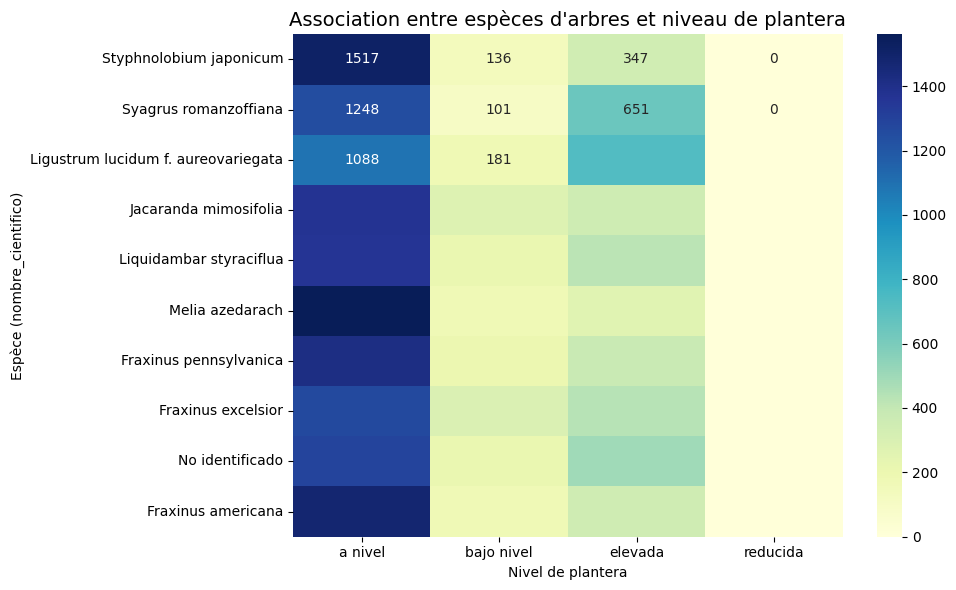

In [48]:
# === 2. Garder les colonnes pertinentes ===
cols = ['nombre_cientifico', 'nivel_plantera', 'ubicacion_plantera']
df_subset = df_balanced[cols].dropna()

# === 3. Table de contingence (espèce ↔ nivel_plantera) ===
tabla_nivel = pd.crosstab(df_subset['nombre_cientifico'], df_subset['nivel_plantera'])

# === 4. Pour visualisation : sélectionner les 10 espèces les plus fréquentes ===
top_species = df_subset['nombre_cientifico'].value_counts().head(10).index
tabla_nivel_top = tabla_nivel.loc[top_species]

# === 5. Créer la carte de chaleur ===
plt.figure(figsize=(10, 6))
sns.heatmap(tabla_nivel_top, cmap="YlGnBu", annot=True, fmt="d")
plt.title("Association entre espèces d'arbres et niveau de plantera", fontsize=14)
plt.xlabel("Nivel de plantera")
plt.ylabel("Espèce (nombre_cientifico)")
plt.tight_layout()
plt.show()

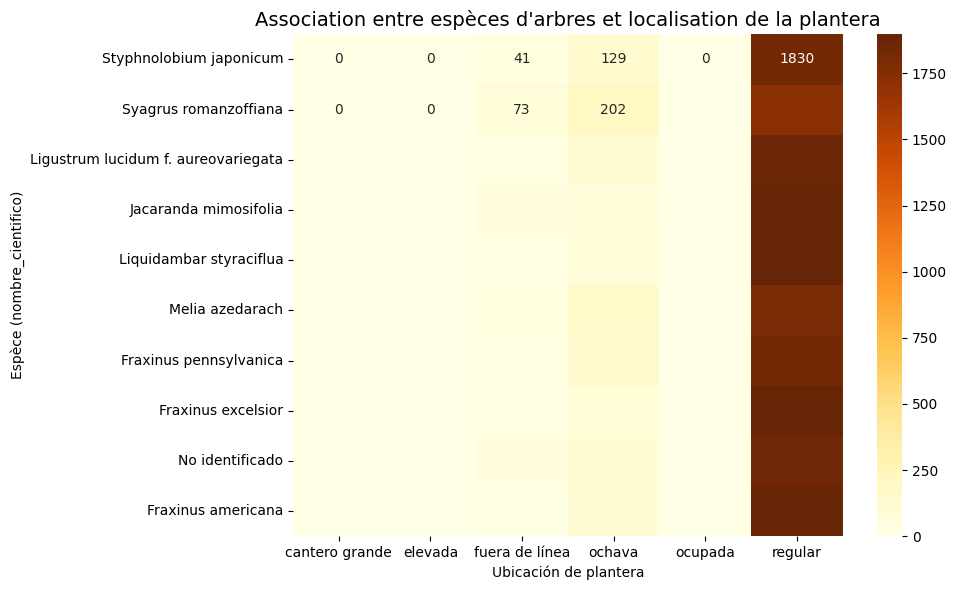

In [46]:
tabla_ubic = pd.crosstab(df_subset['nombre_cientifico'], df_subset['ubicacion_plantera'])
tabla_ubic_top = tabla_ubic.loc[top_species]

plt.figure(figsize=(10, 6))
sns.heatmap(tabla_ubic_top, cmap="YlOrBr", annot=True, fmt="d")
plt.title("Association entre espèces d'arbres et localisation de la plantera", fontsize=14)
plt.xlabel("Ubicación de plantera")
plt.ylabel("Espèce (nombre_cientifico)")
plt.tight_layout()
plt.show()
